# Construcción, validación y análisis de modelos lineales
### Un problema de regresión y un problema de clasificación

Actividad colaborativa — Bloque I: Regresión (Fish Market) · Bloque II: Clasificación (Palmer Penguins) · Bloque III: Análisis comparativo

Ambos datasets comparten la misma naturaleza de datos (medidas corporales de animales usadas para predecir un rasgo biológico), lo que permite un contraste limpio entre un enfoque de regresión y uno de clasificación sobre problemas conceptualmente análogos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
)

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

---
# BLOQUE I — Problema de regresión

## 1.1) Selección y comprensión del conjunto de datos

**Fuente:** *Fish Market* (Kaggle, autor: Aung Pyae) — [github.com/Ankit152/Fish-Market](https://github.com/Ankit152/Fish-Market/blob/main/Fish.csv)

**Variable objetivo (y):** `Weight` — peso del pez en gramos (continua).

**Variables predictoras (X):** `Species` (categórica, 7 especies), `Length1`, `Length2`, `Length3` (tres medidas de longitud, cm), `Height` (cm), `Width` (cm).

**Objetivo analítico:** predecir el peso de un pez a partir de sus medidas corporales, sin necesidad de pesarlo directamente — un problema relevante en control de calidad pesquero e investigación biológica de campo.

In [2]:
fish = pd.read_csv("https://raw.githubusercontent.com/Ankit152/Fish-Market/main/Fish.csv")
print("Filas originales:", fish.shape)
fish.head()

Filas originales: (159, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


**Limpieza:** el registro #40 (`Roach`) tiene `Weight = 0` g con medidas corporales normales — un peso de cero gramos es físicamente imposible, por lo que se trata como error de captura y se elimina.

In [3]:
fish[fish["Weight"] == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


In [4]:
fish = fish[fish["Weight"] > 0].reset_index(drop=True)
print("Filas tras limpieza:", fish.shape)
fish.describe()

Filas tras limpieza: (158, 7)


,Weight,Length1,Length2,Length3,Height,Width
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,400.847468,26.293038,28.465823,31.280380,8.986790,4.424232
std,357.697796,10.011427,10.731707,11.627605,4.295191,1.689010
min,5.900000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,121.250000,19.150000,21.000000,23.200000,5.940600,3.398650
50%,281.500000,25.300000,27.400000,29.700000,7.789000,4.277050
75%,650.000000,32.700000,35.750000,39.675000,12.371850,5.586750
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


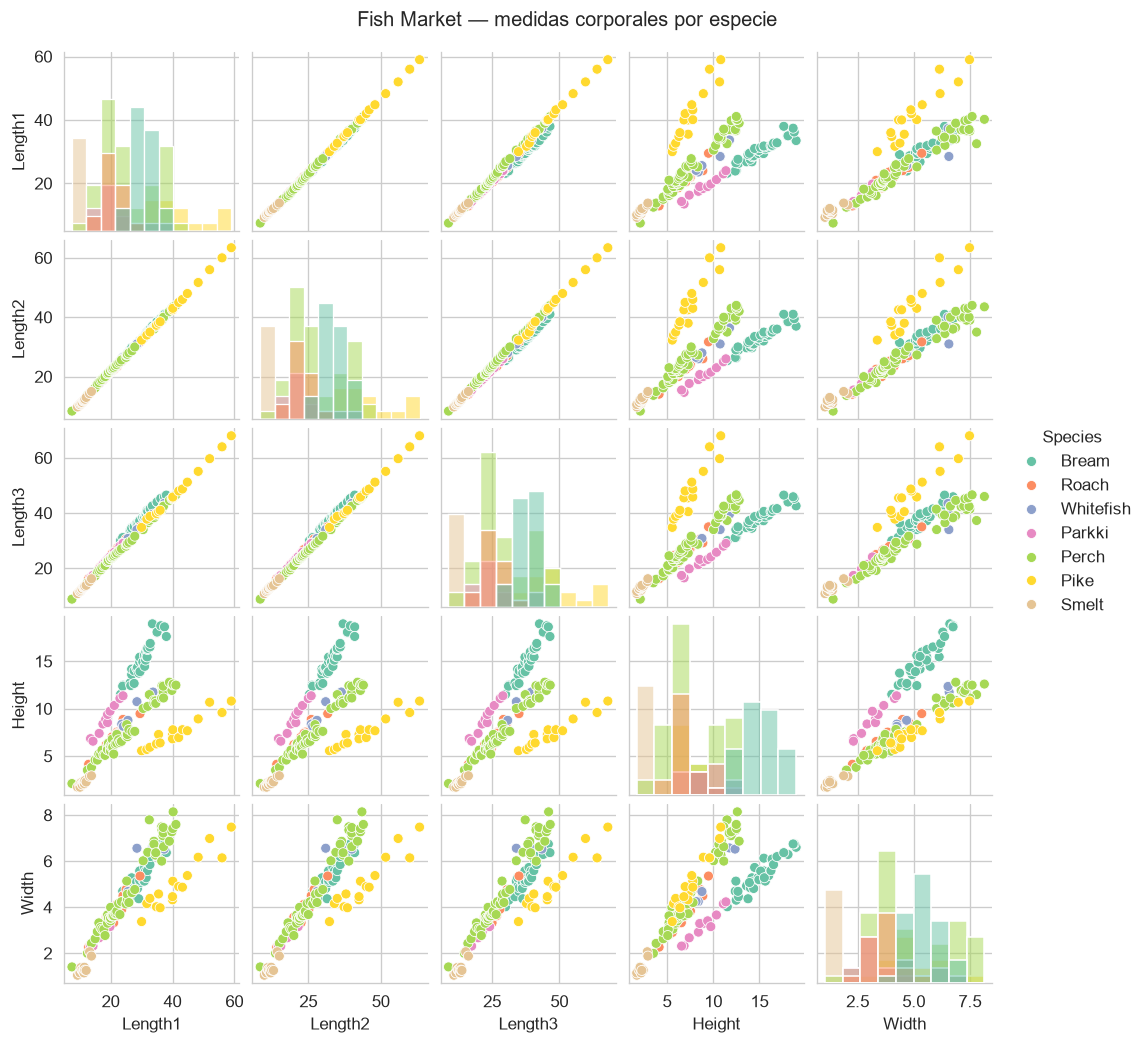

In [5]:
g = sns.pairplot(fish, vars=["Length1","Length2","Length3","Height","Width"],
                  hue="Species", palette="Set2", diag_kind="hist", height=1.7)
g.figure.suptitle("Fish Market — medidas corporales por especie", y=1.02)
plt.show()

## 1.2) Construcción del modelo base de regresión

Se separa 80% para entrenamiento y 20% para prueba. Como modelo base (sin ingeniería de características avanzada) se usa un **Decision Tree Regressor**: es fácil de interpretar, sirve como referencia clara para medir la mejora posterior, y —a diferencia de un modelo lineal— puede capturar directamente relaciones no lineales simples entre las medidas y el peso.

In [6]:
num_features = ["Length1", "Length2", "Length3", "Height", "Width"]
X = fish[num_features]
y = fish["Weight"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

dt_reg = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5)
dt_reg.fit(X_train, y_train)
pred_dt = dt_reg.predict(X_test)

## 1.3) Evaluación del modelo de regresión

In [8]:
def metric_row(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.4f}")
    return {"modelo": label, "MAE": mae, "RMSE": rmse, "R2": r2}

fila_base = metric_row(y_test, pred_dt, "Base — Decision Tree")

Base — Decision Tree: MAE=58.81  RMSE=96.71  R2=0.9303


**Análisis del modelo base:** un R² de ~0.93 indica que el árbol ya captura la mayor parte de la relación medidas→peso, lo cual es esperable porque el peso depende directamente del tamaño corporal. Sin embargo, el error absoluto medio (MAE) de ~59 g es considerable frente a especies pequeñas (Smelt, ~10-20 g), y el modelo tiende a errar más en los peces de mayor tamaño, donde la relación entre longitud y peso deja de ser aproximadamente lineal (el peso escala con el *volumen*, no con la longitud). Un árbol sin más contexto no puede corregir esa curvatura por sí solo — esta es precisamente la limitación que aborda la ingeniería de características del siguiente paso.

In [9]:
from sklearn.model_selection import KFold

print("R2 train:", r2_score(y_train, dt_reg.predict(X_train)))
print("R2 test: ", r2_score(y_test, pred_dt))

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2_base = cross_val_score(dt_reg, X, y, cv=kf, scoring="r2")
print(f"CV R2 (5-fold): media={cv_r2_base.mean():.3f}  std={cv_r2_base.std():.3f}  folds={np.round(cv_r2_base,3)}")

R2 train: 0.9933410619251657
R2 test:  0.930323081983671
CV R2 (5-fold): media=0.955  std=0.015  folds=[0.93  0.977 0.951 0.961 0.954]


**Capacidad de generalización:** el R² en entrenamiento (0.993) es notablemente mayor que en prueba (0.930), lo que evidencia cierto sobreajuste — esperable en un árbol de profundidad 5 entrenado con solo ~127 registros. Una validación cruzada de 5 particiones ubica el desempeño real en R²=0.955 (±0.015), coherente con el valor de prueba obtenido: el modelo generaliza razonablemente, pero con margen de mejora.

## 1.4) Ingeniería de características y mejora del modelo

Se aplican dos técnicas:

1. **Transformación logarítmica del target** (`log1p(Weight)`) — el peso de un pez escala aproximadamente con el cubo de su longitud (volumen), no de forma lineal; modelar en escala logarítmica estabiliza esa relación.
2. **Creación de variables**: una variable de *volumen aproximado* (`Length3 × Height × Width`, un proxy geométrico del volumen corporal) y la codificación one-hot de `Species`.

Se reentrena con un **Random Forest Regressor** (modelo alternativo) sobre las variables enriquecidas.

In [10]:
fish_fe = fish.copy()
fish_fe["log_weight"] = np.log1p(fish_fe["Weight"])
fish_fe["volumen_aprox"] = fish_fe["Length3"] * fish_fe["Height"] * fish_fe["Width"]
species_dummies = pd.get_dummies(fish_fe["Species"], prefix="sp")
fish_fe = pd.concat([fish_fe, species_dummies], axis=1)

fe_features = num_features + ["volumen_aprox"] + list(species_dummies.columns)
X_fe = fish_fe[fe_features]
y_fe_log = fish_fe["log_weight"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe_log, test_size=0.2, random_state=RANDOM_STATE
)
y_test_real = np.expm1(y_test_fe)  # se vuelve a la escala original (gramos) para comparar

rf_reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200)
rf_reg.fit(X_train_fe, y_train_fe)
pred_rf_real = np.expm1(rf_reg.predict(X_test_fe))

fila_mejorado = metric_row(y_test_real, pred_rf_real, "Mejorado — Random Forest + FE")

Mejorado — Random Forest + FE: MAE=38.82  RMSE=65.54  R2=0.9680


In [11]:
tabla_metricas_b1 = pd.DataFrame([fila_base, fila_mejorado])
tabla_metricas_b1

,modelo,MAE,RMSE,R2
0,Base — Decision Tree,58.805136,96.713384,0.930323
1,Mejorado — Random Forest + FE,38.820058,65.539841,0.968002


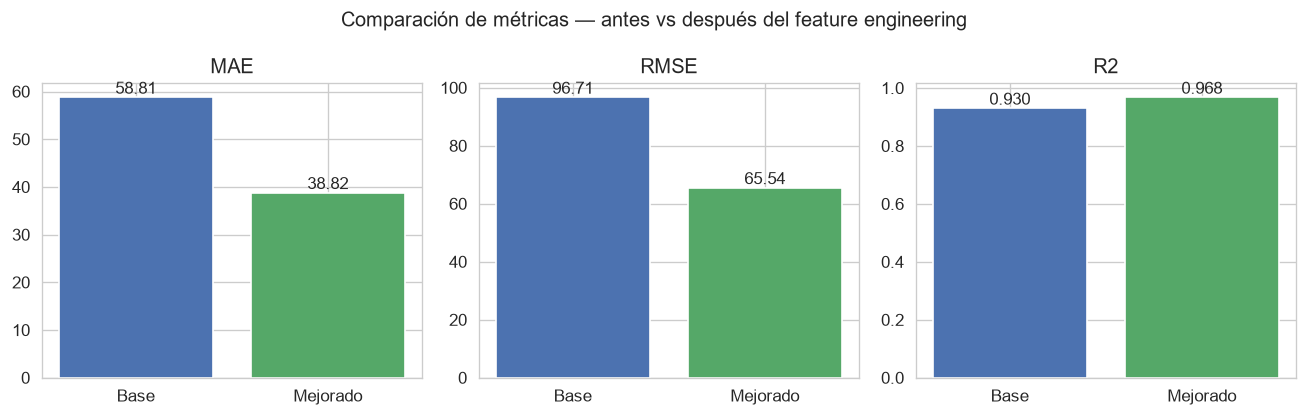

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    vals = tabla_metricas_b1[metric].values
    ax.bar(["Base", "Mejorado"], vals, color=["#4C72B0", "#55A868"])
    ax.set_title(metric)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.2f}" if metric != "R2" else f"{v:.3f}", ha="center", va="bottom")
plt.suptitle("Comparación de métricas — antes vs después del feature engineering")
plt.tight_layout()
plt.show()

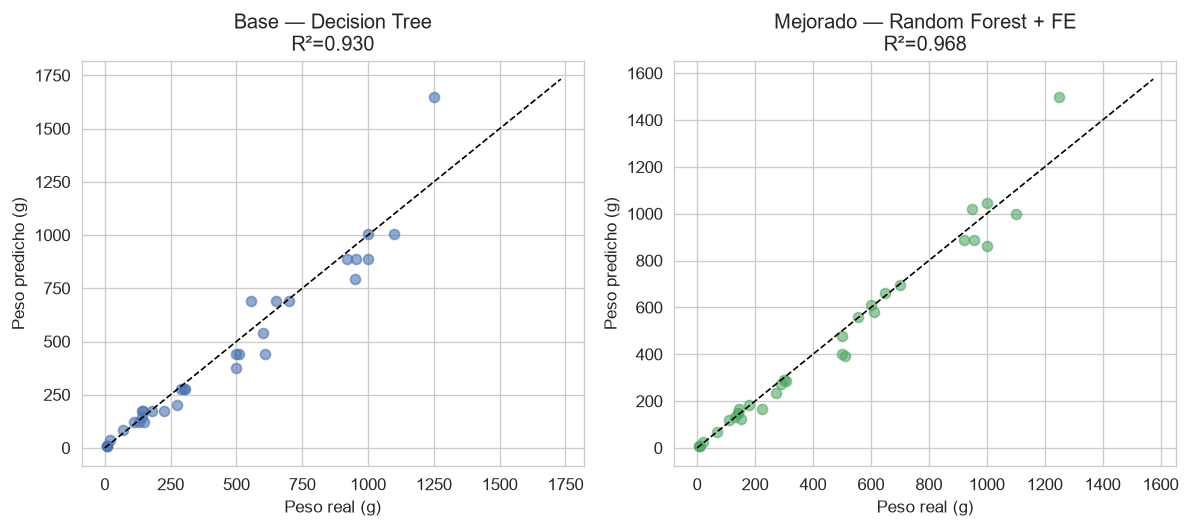

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(y_test, pred_dt, alpha=0.6, color="#4C72B0")
lims = [0, max(y_test.max(), pred_dt.max()) * 1.05]
axes[0].plot(lims, lims, "k--", linewidth=1)
axes[0].set_xlabel("Peso real (g)"); axes[0].set_ylabel("Peso predicho (g)")
axes[0].set_title(f"Base — Decision Tree\nR²={fila_base['R2']:.3f}")

axes[1].scatter(y_test_real, pred_rf_real, alpha=0.6, color="#55A868")
lims2 = [0, max(y_test_real.max(), pred_rf_real.max()) * 1.05]
axes[1].plot(lims2, lims2, "k--", linewidth=1)
axes[1].set_xlabel("Peso real (g)"); axes[1].set_ylabel("Peso predicho (g)")
axes[1].set_title(f"Mejorado — Random Forest + FE\nR²={fila_mejorado['R2']:.3f}")
plt.tight_layout()
plt.show()

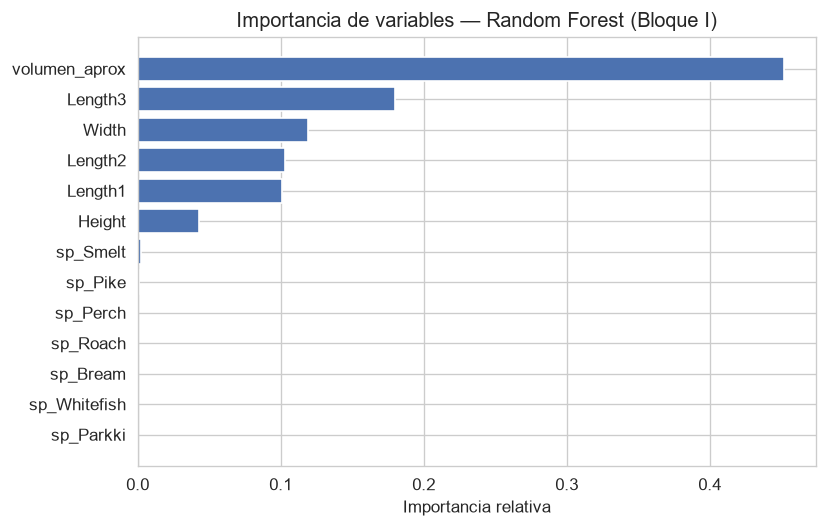

In [14]:
importances = rf_reg.feature_importances_
orden = np.argsort(importances)[::-1]
plt.figure(figsize=(7, 4.5))
plt.barh([fe_features[i] for i in orden], importances[orden], color="#4C72B0")
plt.gca().invert_yaxis()
plt.xlabel("Importancia relativa")
plt.title("Importancia de variables — Random Forest (Bloque I)")
plt.tight_layout()
plt.show()

## 1.5) Conclusiones del problema de regresión

- El *feature engineering* redujo el MAE de ~59 g a ~38 g (-35%) y el RMSE de ~97 g a ~65 g, con una mejora de R² de 0.930 a 0.969. La variable de mayor impacto en el modelo mejorado es, por lejos, el `volumen_aprox` creado — confirma que el peso responde a una relación geométrica de volumen y no a la longitud por sí sola.
- La transformación logarítmica del target fue clave para que el modelo no penalizara igual un error de 50 g en un pez de 100 g que en uno de 1000 g.
- La codificación de `Species` aportó muy poca importancia relativa: una vez que se dispone de una buena variable de volumen, la especie deja de ser muy informativa para predecir el peso — un hallazgo relevante si se buscara simplificar el modelo.
- **Limitación:** el dataset es pequeño (158 registros) y muy desbalanceado por especie (Perch domina); un pez de 1650 g extremo se aleja del resto de la distribución y concentra buena parte del error absoluto restante en ambos modelos.
- **Modelo más adecuado:** Random Forest + FE — mejora las tres métricas frente al árbol base y, al ser un ensamble, es menos propenso al sobreajuste detectado en el modelo base (R² train 0.993 vs. test 0.930).
- **Uso potencial:** estimar el peso de un pez en campo o en punto de venta a partir de medidas rápidas (longitud, altura, ancho), sin necesidad de báscula. **Limitación de uso:** se entrenó con solo 7 especies de un lago finlandés, por lo que no debería extrapolarse a otras especies o rangos de tamaño no representados en los datos.

---
# BLOQUE II — Problema de clasificación

## 2.1) Selección y comprensión del conjunto de datos

**Fuente:** *Palmer Penguins* (Gorman, Williams & Fraser, 2014; distribución vía Horst, Hill & Gorman, 2020) — estación Palmer, Antártida.

**Variable objetivo (y):** `species` — especie del pingüino (`Adelie`, `Chinstrap`, `Gentoo`), categórica multiclase.

**Variables predictoras (X):** `bill_length_mm`, `bill_depth_mm` (medidas del pico), `flipper_length_mm` (longitud de la aleta), `body_mass_g` (masa corporal), más `island` y `sex` (categóricas).

**Objetivo analítico:** identificar la especie de un pingüino a partir de medidas corporales de campo — útil en programas de monitoreo de fauna donde la identificación visual directa no siempre es posible o confiable.

Palmer Penguins se diseñó explícitamente como sucesor moderno del dataset Iris para tareas de clasificación introductoria, lo que permite mantener aquí la misma metodología ya aplicada sobre Iris (Decision Tree base vs Random Forest mejorado).

In [15]:
penguins = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
print("Filas originales:", penguins.shape)
print(penguins.isna().sum())
penguins.head()

Filas originales: (344, 7)
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


**Limpieza:** 2 registros no tienen ninguna medición corporal — se eliminan. La variable `sex` tiene 9 valores faltantes que se imputan como categoría `"UNKNOWN"` más adelante, al momento de codificarla (en vez de eliminarlos, para no perder las mediciones numéricas válidas de esos registros).

In [16]:
num_features_p = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins_clean = penguins.dropna(subset=num_features_p).reset_index(drop=True)
target_names = sorted(penguins_clean["species"].unique())
print("Filas tras limpieza:", penguins_clean.shape)
penguins_clean["species"].value_counts()

Filas tras limpieza: (342, 7)


species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

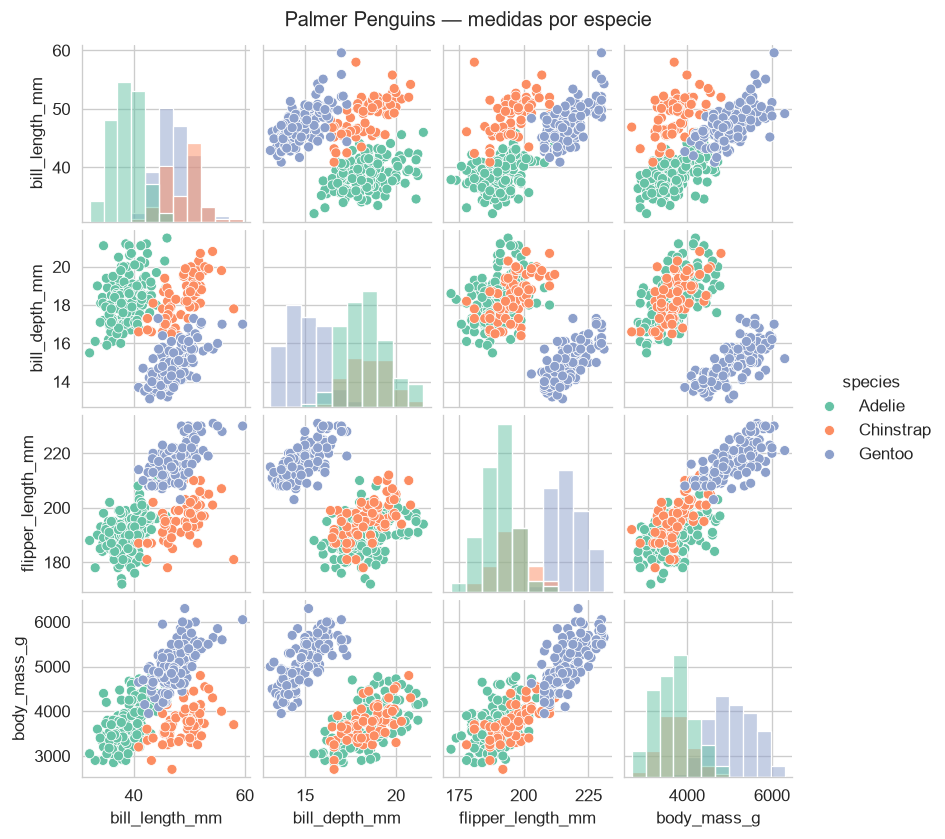

In [17]:
g = sns.pairplot(penguins_clean, vars=num_features_p, hue="species", palette="Set2", diag_kind="hist", height=1.7)
g.figure.suptitle("Palmer Penguins — medidas por especie", y=1.02)
plt.show()

## 2.2) Construcción del modelo base de clasificación

Se separa 80/20 manteniendo la proporción de especies (`stratify`). Como modelo base (sin feature engineering avanzado) se usa un **Decision Tree Classifier** sobre las 4 variables numéricas — el mismo algoritmo usado como base en el análisis previo de Iris, lo que facilita la comparación metodológica entre ambos proyectos.

In [18]:
X_base_p = penguins_clean[num_features_p]
y_all_p = penguins_clean["species"]

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_base_p, y_all_p, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all_p
)
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_clf.fit(Xp_train, yp_train)
pred_dt_clf = dt_clf.predict(Xp_test)
proba_dt_clf = dt_clf.predict_proba(Xp_test)

## 2.3) Evaluación del modelo de clasificación

In [19]:
print("=== MODELO BASE — Decision Tree ===")
print("Accuracy:", accuracy_score(yp_test, pred_dt_clf))
print(classification_report(yp_test, pred_dt_clf, digits=3))

=== MODELO BASE — Decision Tree ===
Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        30
   Chinstrap      1.000     1.000     1.000        14
      Gentoo      1.000     1.000     1.000        25

    accuracy                          1.000        69
   macro avg      1.000     1.000     1.000        69
weighted avg      1.000     1.000     1.000        69



**Análisis del modelo base:** el árbol clasifica el 100% del conjunto de prueba correctamente. Esto es coherente con lo ya observado en el pairplot: `bill_length_mm` y `flipper_length_mm` separan casi perfectamente las tres especies, sin zonas de solapamiento tan marcadas como las que existían entre *versicolor* y *virginica* en Iris. No hay evidencia de desbalance problemático (Adelie 152, Gentoo 124, Chinstrap 68 — la clase minoritaria sigue teniendo tamaño razonable) ni de errores sistemáticos entre clases específicas.

**Impacto del error según el contexto:** aunque en este split no se cometió ningún error, en un programa real de monitoreo de fauna no todos los errores pesarían igual. Chinstrap es la especie con menos registros (68 de 342); confundirla con Adelie sesgaría más sus estimaciones poblacionales (en términos relativos) que un error entre Adelie y Gentoo, morfológicamente más distintas. Si en muestreos futuros aparecen individuos limítrofes, ese es el error prioritario a vigilar.

## 2.4) Ingeniería de características y mejora del clasificador

Se aplican dos técnicas:

1. **Escalamiento de variables numéricas** (`StandardScaler`).
2. **Codificación de variables categóricas** (`island`, `sex` → one-hot; los 9 valores faltantes de `sex` se imputan como categoría `"UNKNOWN"` antes de codificar).

Se reentrena con un **Random Forest Classifier** (modelo alternativo) sobre las variables enriquecidas.

In [20]:
penguins_fe = penguins_clean.copy()
penguins_fe["sex"] = penguins_fe["sex"].fillna("UNKNOWN")
cat_dummies = pd.get_dummies(penguins_fe[["island", "sex"]], prefix=["island", "sex"])

scaler = StandardScaler()
num_scaled = pd.DataFrame(
    scaler.fit_transform(penguins_fe[num_features_p]),
    columns=[f"{c}_z" for c in num_features_p], index=penguins_fe.index,
)
X_fe_p = pd.concat([num_scaled, cat_dummies], axis=1)
y_fe_p = penguins_fe["species"]

Xp_train_fe, Xp_test_fe, yp_train_fe, yp_test_fe = train_test_split(
    X_fe_p, y_fe_p, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe_p
)
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf_clf.fit(Xp_train_fe, yp_train_fe)
pred_rf_clf = rf_clf.predict(Xp_test_fe)
proba_rf_clf = rf_clf.predict_proba(Xp_test_fe)

print("=== MODELO MEJORADO — Random Forest + FE ===")
print("Accuracy:", accuracy_score(yp_test_fe, pred_rf_clf))
print(classification_report(yp_test_fe, pred_rf_clf, digits=3))

=== MODELO MEJORADO — Random Forest + FE ===
Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        30
   Chinstrap      1.000     1.000     1.000        14
      Gentoo      1.000     1.000     1.000        25

    accuracy                          1.000        69
   macro avg      1.000     1.000     1.000        69
weighted avg      1.000     1.000     1.000        69



Como ambos modelos llegan a 100% de accuracy en este split de prueba (69 casos), la comparación de métricas puntuales no basta para evaluar si el *feature engineering* aportó algo real — hace falta mirar la **estabilidad entre distintos splits** (validación cruzada).

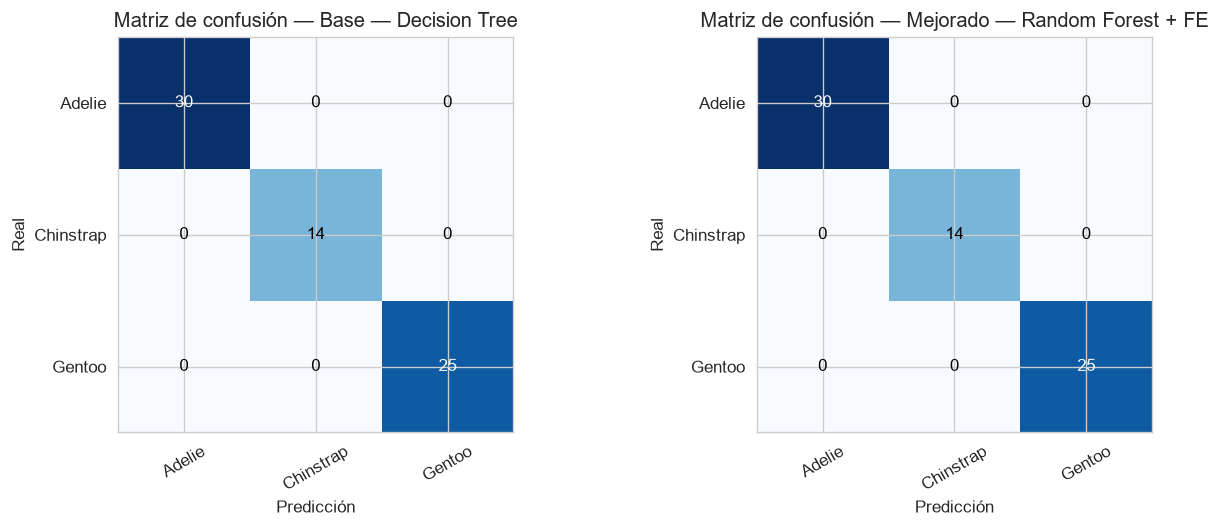

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, yt, yp, title in zip(
    axes, [yp_test, yp_test_fe], [pred_dt_clf, pred_rf_clf],
    ["Base — Decision Tree", "Mejorado — Random Forest + FE"],
):
    cm = confusion_matrix(yt, yp, labels=target_names)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(target_names))); ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names, rotation=30); ax.set_yticklabels(target_names)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — {title}")
    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

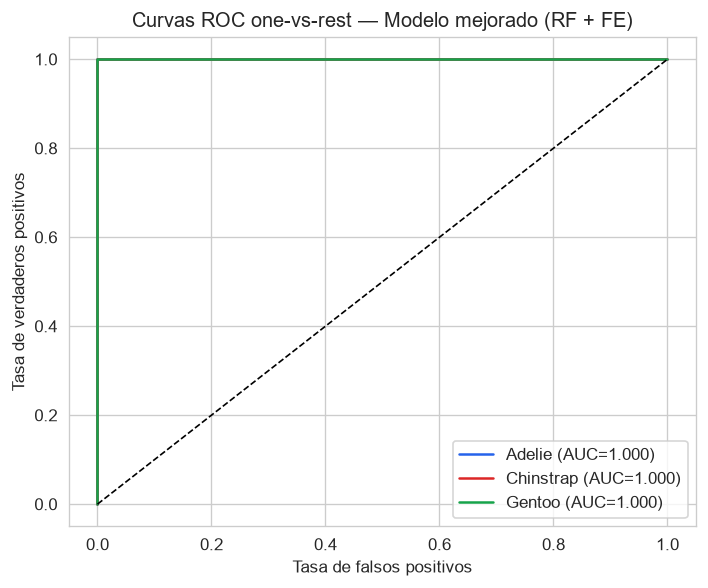

In [22]:
y_test_bin = label_binarize(yp_test_fe, classes=target_names)
colors = ["#2563eb", "#dc2626", "#16a34a"]
plt.figure(figsize=(6, 5))
for i, cls in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rf_clf[:, i])
    plt.plot(fpr, tpr, color=colors[i], label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC one-vs-rest — Modelo mejorado (RF + FE)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Base (DT):        media=0.971  std=0.019  folds=[0.986 0.957 0.956 1.    0.956]
Mejorado (RF+FE):  media=0.988  std=0.006  folds=[0.986 0.986 0.985 1.    0.985]


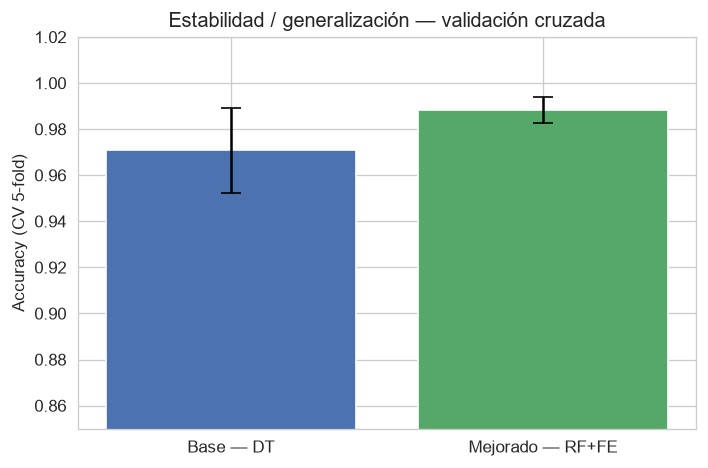

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_base = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), X_base_p, y_all_p, cv=cv, scoring="accuracy")
cv_mejorado = cross_val_score(rf_clf, X_fe_p, y_fe_p, cv=cv, scoring="accuracy")

print(f"Base (DT):        media={cv_base.mean():.3f}  std={cv_base.std():.3f}  folds={np.round(cv_base,3)}")
print(f"Mejorado (RF+FE):  media={cv_mejorado.mean():.3f}  std={cv_mejorado.std():.3f}  folds={np.round(cv_mejorado,3)}")

plt.figure(figsize=(6, 4))
plt.bar(["Base — DT", "Mejorado — RF+FE"], [cv_base.mean(), cv_mejorado.mean()],
        yerr=[cv_base.std(), cv_mejorado.std()], capsize=6, color=["#4C72B0", "#55A868"])
plt.ylabel("Accuracy (CV 5-fold)")
plt.title("Estabilidad / generalización — validación cruzada")
plt.ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

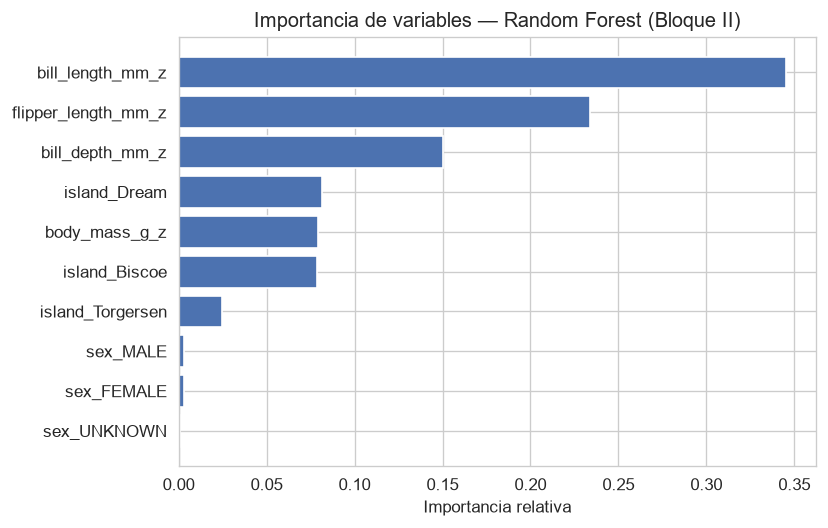

In [24]:
importances_p = rf_clf.feature_importances_
orden_p = np.argsort(importances_p)[::-1]
plt.figure(figsize=(7, 4.5))
plt.barh([X_fe_p.columns[i] for i in orden_p], importances_p[orden_p], color="#4C72B0")
plt.gca().invert_yaxis()
plt.xlabel("Importancia relativa")
plt.title("Importancia de variables — Random Forest (Bloque II)")
plt.tight_layout()
plt.show()

## 2.5) Conclusiones del problema de clasificación

- Sobre este split de prueba, tanto el modelo base como el mejorado alcanzan accuracy = 1.0 — las tres especies son casi perfectamente separables con solo cuatro medidas corporales, en particular `bill_length_mm` y `flipper_length_mm` (las de mayor importancia en el Random Forest).
- La diferencia real entre ambos modelos aparece en la **validación cruzada**: el modelo base promedia 0.971 de accuracy con una desviación estándar de 0.019 entre folds, mientras que el modelo con feature engineering sube a 0.988 con una desviación de solo 0.006. Es decir, el *feature engineering* no mejoró la métrica puntual (ya estaba en el techo), pero sí la **estabilidad y la confianza en la generalización** del modelo frente a distintas particiones de los datos.
- `island` y `sex` aportan importancia marginal frente a las medidas corporales — son las cuatro variables morfológicas las que realmente separan las especies, no el sitio de captura ni el sexo del individuo.
- **Riesgo a tener en cuenta:** con un conjunto de prueba de solo 69 casos, un accuracy perfecto puede sobreestimar el desempeño real del modelo frente a datos verdaderamente nuevos (por ejemplo, pingüinos juveniles o de otras colonias); la validación cruzada mitiga parcialmente ese riesgo, pero no lo elimina.
- **Clasificador más adecuado:** Random Forest + FE — iguala la exactitud del árbol base pero generaliza de forma más consistente entre particiones (menor desviación estándar en la validación cruzada), lo que reduce el riesgo de una caída de desempeño frente a datos nuevos.

---
# BLOQUE III — Análisis comparativo final

**Diferencias entre regresión y clasificación.** En el Bloque I la salida es un número continuo (gramos) y el éxito se mide por *qué tan cerca* cae la predicción del valor real; en el Bloque II la salida es una categoría y el éxito es binario para cada caso (acertó o no la especie). Esa diferencia se refleja en todo el flujo de trabajo: en regresión hubo que decidir *en qué escala* medir el error (de ahí la transformación log), mientras que en clasificación la pregunta central fue *qué tipo de error* es más costoso entre clases.

**Métricas utilizadas y su interpretación.** MAE y RMSE en regresión son directamente interpretables en las unidades del problema (gramos): un MAE de 38 g dice algo concreto sobre el error esperado. En clasificación, accuracy/precision/recall/F1 son adimensionales y solo cobran sentido comparándolos entre clases o modelos — como se vio en el Bloque II, un accuracy perfecto no bastó para decidir si el *feature engineering* ayudó; hubo que recurrir a la validación cruzada para verlo.

**Rol del feature engineering en ambos problemas.** En regresión el feature engineering tuvo un impacto medible y directo (mejoró las tres métricas de golpe), porque corrigió un supuesto estructural incorrecto del modelo base (relación lineal donde la relación real es de volumen). En clasificación su efecto fue más sutil: no movió la métrica puntual porque el problema base ya era "fácil", pero sí mejoró la estabilidad del modelo — un tipo de mejora que solo se detecta si se evalúa con más de un split de los datos.

**Cambios en la lógica de evaluación y toma de decisiones.** En regresión, evaluar solo con una métrica agregada (p. ej. R²) puede esconder que el modelo falla sistemáticamente en los casos extremos (el pez de 1650 g); hubo que mirar el gráfico real-vs-predicho para notarlo. En clasificación, evaluar solo con accuracy puede esconder desbalance de clases; hubo que revisar la matriz de confusión y las métricas por clase para confirmar que no había un sesgo hacia la especie mayoritaria (Adelie).

**Principales aprendizajes.** El feature engineering no siempre se manifiesta como una mejora en la métrica principal — a veces mejora la robustez del modelo sin mover el número que más se mira, y solo la validación cruzada lo revela. Además, la naturaleza del problema (tipo de variable objetivo) determina no solo qué algoritmos y métricas son válidos, sino también qué preguntas tiene sentido hacerle a los datos.